# Exploracion de datos - Siniestros sinteticos

Este notebook realiza el preprocesamiento basico, guarda tablas en `data/raw`, y ejecuta un EDA end-to-end con graficos descriptivos.

In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

In [17]:
# Paths
ROOT = Path("..").resolve()
DATA_SYNTH = ROOT / "data" / "synthetic"
DATA_RAW = ROOT / "data" / "raw"
DATA_RAW.mkdir(parents=True, exist_ok=True)

files = {
    "siniestros": DATA_SYNTH / "siniestros_100_registros.csv",
    "asegurados": DATA_SYNTH / "asegurados_sinteticos.csv",
    "polizas": DATA_SYNTH / "polizas.csv",
    "documentos": DATA_SYNTH / "documentos.csv",
    "beneficiarios_proveedores": DATA_SYNTH / "beneficiarios_proveedores.csv",
    "vehiculos": DATA_SYNTH / "vehiculos.csv",
}

files

{'siniestros': WindowsPath('C:/Users/H P/Desktop/hackAIthon/fraudIA-Novo-2S1R/data/synthetic/siniestros_100_registros.csv'),
 'asegurados': WindowsPath('C:/Users/H P/Desktop/hackAIthon/fraudIA-Novo-2S1R/data/synthetic/asegurados_sinteticos.csv'),
 'polizas': WindowsPath('C:/Users/H P/Desktop/hackAIthon/fraudIA-Novo-2S1R/data/synthetic/polizas.csv'),
 'documentos': WindowsPath('C:/Users/H P/Desktop/hackAIthon/fraudIA-Novo-2S1R/data/synthetic/documentos.csv'),
 'beneficiarios_proveedores': WindowsPath('C:/Users/H P/Desktop/hackAIthon/fraudIA-Novo-2S1R/data/synthetic/beneficiarios_proveedores.csv'),
 'vehiculos': WindowsPath('C:/Users/H P/Desktop/hackAIthon/fraudIA-Novo-2S1R/data/synthetic/vehiculos.csv')}

In [18]:
# Lectura truncada para inspeccion
preview = {name: pd.read_csv(path, nrows=8) for name, path in files.items()}
{name: df.head(3) for name, df in preview.items()}

{'siniestros':    id_siniestro  id_poliza  id_asegurado  id_proveedor   ramo                 cobertura fecha_ocurrencia fecha_reporte  monto_reclamado  monto_estimado  monto_pagado                   estado  \
 0             1          1            50            28   OTRO        Cobertura especial       2026-05-11    2026-05-27          4830.07         4173.47          0.00  CIERRE_SIN_CONSECUENCIA   
 1             2          2             8            11  HOGAR  Responsabilidad familiar       2025-09-17    2025-09-27          2482.29         1985.12       1540.39               PAGO_TOTAL   
 2             3          3            56            15  HOGAR         Robo domiciliario       2023-11-23    2023-12-09         39825.18        39104.68      38351.48               PAGO_TOTAL   
 
            sucursal                                        descripcion  documentos_completos beneficiario  dias_desde_inicio_poliza  dias_desde_fin_poliza  dias_entre_ocurrencia_reporte  \
 0    Sucursal

In [19]:
# Tipado basico y limpieza ligera
def to_datetime(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

def to_bool(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower().map({"true": True, "false": False})
    return df

def to_numeric(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def normalize_columns(df):
    df.columns = [c.strip() for c in df.columns]
    return df

def preprocess_tables(files_dict):
    tables = {}
    for name, path in files_dict.items():
        df = pd.read_csv(path)
        df = normalize_columns(df)

        if name == "siniestros":
            df = to_datetime(df, ["fecha_ocurrencia", "fecha_reporte", "created_at", "updated_at"])
            df = to_bool(df, ["documentos_completos"])
            df = to_numeric(
                df,
                [
                    "monto_reclamado",
                    "monto_estimado",
                    "monto_pagado",
                    "dias_desde_inicio_poliza",
                    "dias_desde_fin_poliza",
                    "dias_entre_ocurrencia_reporte",
                    "historial_siniestros_asegurado",
                    "etiqueta_fraude_simulada",
                ],
            )
        elif name == "asegurados":
            df = to_datetime(df, ["created_at", "updated_at"])
            df = to_numeric(df, ["antiguedad_meses", "numero_polizas", "reclamos_ultimos_12_meses", "mora_actual", "score_cliente_simulado"])
        elif name == "polizas":
            df = to_datetime(df, ["fecha_inicio", "fecha_fin", "created_at", "updated_at"])
            df = to_numeric(df, ["prima", "suma_asegurada", "deducible"])
        elif name == "documentos":
            df = to_datetime(df, ["fecha_emision", "created_at", "updated_at"])
            df = to_bool(df, ["entregado", "legible", "inconsistencia_detectada"])
        elif name == "beneficiarios_proveedores":
            df = to_datetime(df, ["created_at", "updated_at"])
            df = to_numeric(df, ["reclamos_asociados", "monto_promedio_reclamado", "porcentaje_casos_observados", "antiguedad_meses"])
        elif name == "vehiculos":
            df = to_datetime(df, ["created_at", "updated_at"])
            df = to_numeric(df, ["anio"])

        tables[name] = df
    return tables

tables = preprocess_tables(files)
{name: df.dtypes for name, df in tables.items()}

{'siniestros': id_siniestro                               int64
 id_poliza                                  int64
 id_asegurado                               int64
 id_proveedor                             float64
 ramo                                      object
 cobertura                                 object
 fecha_ocurrencia                  datetime64[ns]
 fecha_reporte                     datetime64[ns]
 monto_reclamado                          float64
 monto_estimado                           float64
 monto_pagado                             float64
 estado                                    object
 sucursal                                  object
 descripcion                               object
 documentos_completos                        bool
 beneficiario                              object
 dias_desde_inicio_poliza                   int64
 dias_desde_fin_poliza                      int64
 dias_entre_ocurrencia_reporte              int64
 historial_siniestros_asegurado     

In [20]:
# Guardar preprocesados en data/raw
for name, df in tables.items():
    out_path = DATA_RAW / f"{name}.csv"
    df.to_csv(out_path, index=False)

sorted([p.name for p in DATA_RAW.glob("*.csv")])

['asegurados.csv',
 'beneficiarios_proveedores.csv',
 'documentos.csv',
 'polizas.csv',
 'siniestros.csv',
 'vehiculos.csv']

## EDA: vision general

In [21]:
siniestros = tables["siniestros"].copy()
siniestros.head()

,id_siniestro,id_poliza,id_asegurado,id_proveedor,ramo,cobertura,fecha_ocurrencia,fecha_reporte,monto_reclamado,monto_estimado,monto_pagado,estado,sucursal,descripcion,documentos_completos,beneficiario,dias_desde_inicio_poliza,dias_desde_fin_poliza,dias_entre_ocurrencia_reporte,historial_siniestros_asegurado,etiqueta_fraude_simulada,created_at,updated_at
0,1,1,50,28.0,OTRO,Cobertura especial,2026-05-11,2026-05-27,4830.07,4173.47,0.00,CIERRE_SIN_CONSECUENCIA,Sucursal Manta,Siniestro simulado de ramo otro por cobertura ...,True,CLINICA,348,-17,16,0,0,2026-05-15 09:47:00,2026-05-18 12:08:00
1,2,2,8,11.0,HOGAR,Responsabilidad familiar,2025-09-17,2025-09-27,2482.29,1985.12,1540.39,PAGO_TOTAL,Matriz Guayaquil,Siniestro simulado de ramo hogar por cobertura...,True,PERITO,303,-427,10,0,0,2026-05-16 10:54:00,2026-05-19 13:15:00
2,3,3,56,15.0,HOGAR,Robo domiciliario,2023-11-23,2023-12-09,39825.18,39104.68,38351.48,PAGO_TOTAL,Sucursal Manta,Siniestro simulado de ramo hogar por cobertura...,False,PERITO,275,-90,16,0,0,2026-05-17 11:01:00,2026-05-20 14:22:00
3,4,4,13,4.0,SALUD,Hospitalización,2024-01-20,2024-01-22,27810.18,24813.58,0.00,NEGATIVA,Sucursal Cuenca,Siniestro simulado de ramo salud por cobertura...,True,TALLER,189,-176,2,0,0,2026-05-18 12:08:00,2026-05-21 15:29:00
4,5,5,56,26.0,VIDA,Enfermedad grave,2023-09-24,2023-10-05,4730.35,4924.49,381.04,ANTICIPO,Sucursal Cuenca,Siniestro simulado de ramo vida por cobertura ...,True,CLINICA,134,-46,11,1,0,2026-05-19 13:15:00,2026-05-22 16:36:00


In [22]:
siniestros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id_siniestro                    100 non-null    int64         
 1   id_poliza                       100 non-null    int64         
 2   id_asegurado                    100 non-null    int64         
 3   id_proveedor                    86 non-null     float64       
 4   ramo                            100 non-null    object        
 5   cobertura                       100 non-null    object        
 6   fecha_ocurrencia                100 non-null    datetime64[ns]
 7   fecha_reporte                   100 non-null    datetime64[ns]
 8   monto_reclamado                 100 non-null    float64       
 9   monto_estimado                  100 non-null    float64       
 10  monto_pagado                    100 non-null    float64       
 11  estado 

In [23]:
siniestros.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_siniestro,100.0,NaN,NaN,NaN,50.5,1.0,25.75,50.5,75.25,100.0,29.011492
id_poliza,100.0,NaN,NaN,NaN,50.5,1.0,25.75,50.5,75.25,100.0,29.011492
id_asegurado,100.0,NaN,NaN,NaN,31.53,1.0,16.75,33.0,47.0,60.0,17.324855
id_proveedor,86.0,NaN,NaN,NaN,18.337209,1.0,12.0,18.0,24.0,35.0,8.702414
ramo,100,6,VEHICULOS,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cobertura,100,25,Cirugía ambulatoria,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_ocurrencia,100,NaN,NaN,NaN,2024-11-28 18:28:48,2023-03-06 00:00:00,2024-04-05 12:00:00,2024-11-27 12:00:00,2025-07-20 00:00:00,2026-05-19 00:00:00,NaN
fecha_reporte,100,NaN,NaN,NaN,2024-12-13 09:36:00,2023-03-12 00:00:00,2024-04-25 06:00:00,2024-12-13 00:00:00,2025-08-04 12:00:00,2026-05-27 00:00:00,NaN
monto_reclamado,100.0,NaN,NaN,NaN,18045.9892,417.87,5370.4725,10508.79,23782.52,114940.44,19339.758994
monto_estimado,100.0,NaN,NaN,NaN,16497.5492,418.65,5034.995,9278.44,22350.6125,114131.6,18084.280667


In [24]:
# Nulos por columna
(siniestros.isna().mean().sort_values(ascending=False) * 100).to_frame("pct_null").head(15)

,pct_null
id_proveedor,14.0
beneficiario,5.0
id_poliza,0.0
id_asegurado,0.0
ramo,0.0
cobertura,0.0
id_siniestro,0.0
fecha_ocurrencia,0.0
fecha_reporte,0.0
monto_estimado,0.0


**Insight**: En siniestros, `id_proveedor` tiene 14% de nulos y `beneficiario` 5%. Estos faltantes se trataran como ausencia de proveedor/beneficiario en el feature engineering (por ejemplo, proveedor no identificado).

## Distribucion de la variable objetivo

**Descripcion**: Muestra el balance de clases entre fraude (1) y no fraude (0). En este dataset sintetico hay mas casos no fraude, por lo que el modelo debe considerar el desbalance para evitar sesgos en precision/recall.

**Insight**: La etiqueta esta desbalanceada (85 no fraude vs 15 fraude). Se recomienda usar metricas como recall y AUC, y considerar ponderacion de clases en el entrenamiento.

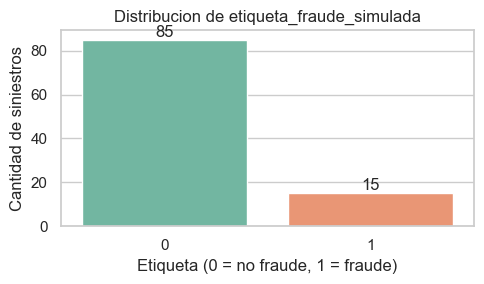

In [25]:
plt.figure(figsize=(5, 3))
ax = sns.countplot(x="etiqueta_fraude_simulada", data=siniestros, hue="etiqueta_fraude_simulada", palette="Set2", legend=False)
ax.set_title("Distribucion de etiqueta_fraude_simulada")
ax.set_xlabel("Etiqueta (0 = no fraude, 1 = fraude)")
ax.set_ylabel("Cantidad de siniestros")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

## Distribuciones numericas

**Descripcion**: Distribuciones de montos y tiempos. Se observan colas largas en montos y variabilidad en dias entre ocurrencia y reporte, lo cual es util para señales de riesgo. Revisar outliers altos para reglas de monto cercano a suma asegurada.

**Insight**: `monto_reclamado` tiene media ~18k y max ~115k, con cola larga; `dias_entre_ocurrencia_reporte` va de 0 a 30 dias (media ~14.6). Estos rangos permiten definir umbrales de reporte tardio y montos atipicos.

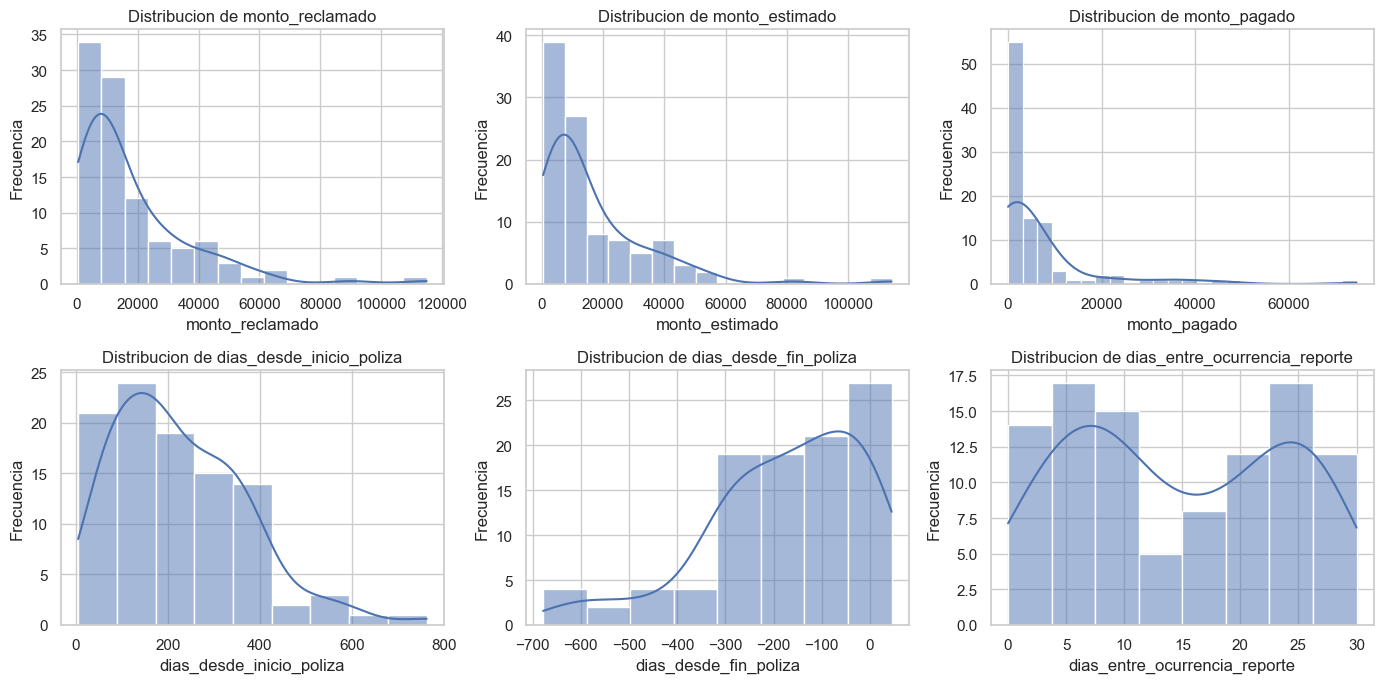

In [26]:
num_cols = [
    "monto_reclamado",
    "monto_estimado",
    "monto_pagado",
    "dias_desde_inicio_poliza",
    "dias_desde_fin_poliza",
    "dias_entre_ocurrencia_reporte",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(siniestros[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribucion de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## Variables categoricas

**Descripcion**: Frecuencias de ramo, cobertura, estado, sucursal y beneficiario. Esta distribucion ayuda a priorizar segmentos con mayor volumen y detectar categorias con baja representatividad.

**Insight**: `VEHICULOS` y `SALUD` son los ramos mas frecuentes (28 casos cada uno) y `Cirugia ambulatoria` la cobertura mas repetida (10 casos). Estos segmentos deben tener suficiente representatividad en el entrenamiento y en validaciones estratificadas.

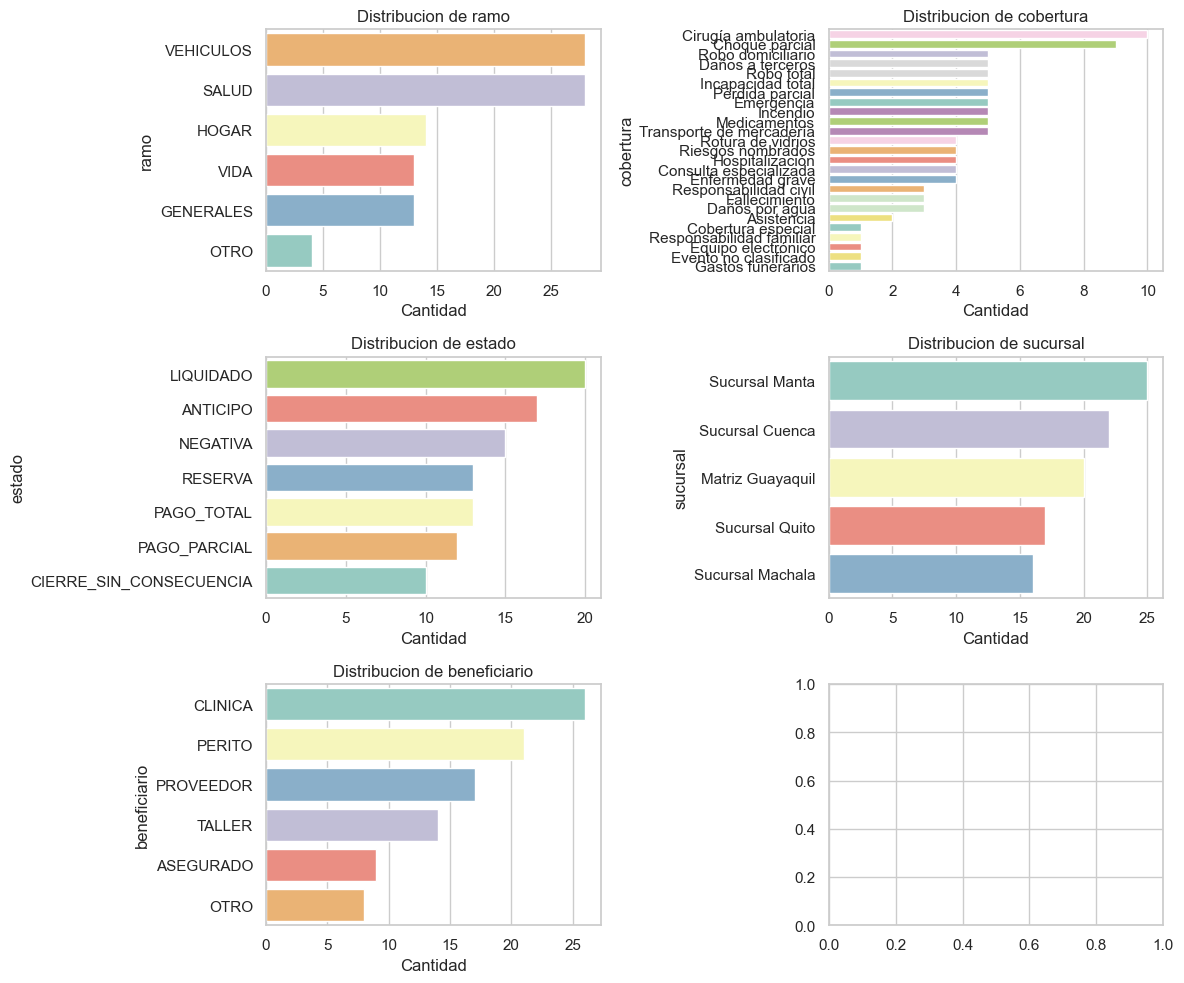

In [27]:
cat_cols = ["ramo", "cobertura", "estado", "sucursal", "beneficiario"]
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(y=col, data=siniestros, ax=axes[i], order=siniestros[col].value_counts().index, hue=col, palette="Set3", legend=False)
    axes[i].set_title(f"Distribucion de {col}")
    axes[i].set_xlabel("Cantidad")
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

## Relaciones con etiqueta de fraude

**Descripcion**: Comparacion de variables clave por etiqueta. Si los fraudes muestran montos o tiempos mayores, estas variables son candidatas para scoring.

**Insight**: Los boxplots permiten contrastar si los casos fraude concentran valores mas altos en monto reclamado o en dias de reporte. Este contraste alimentara las reglas de reporte tardio y montos cercanos a suma asegurada.

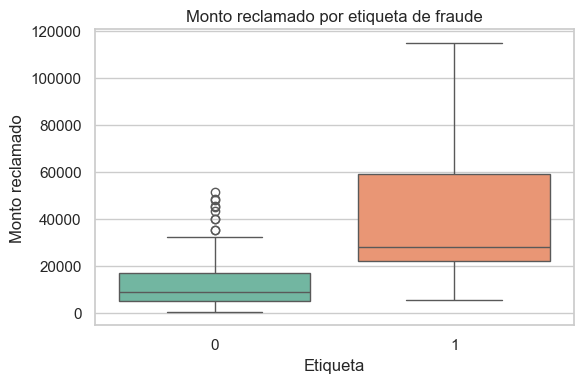

In [28]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="etiqueta_fraude_simulada", y="monto_reclamado", data=siniestros, hue="etiqueta_fraude_simulada", palette="Set2", legend=False)
plt.title("Monto reclamado por etiqueta de fraude")
plt.xlabel("Etiqueta")
plt.ylabel("Monto reclamado")
plt.tight_layout()
plt.show()

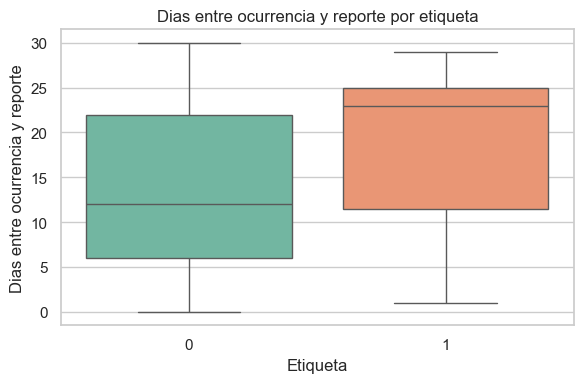

In [29]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="etiqueta_fraude_simulada", y="dias_entre_ocurrencia_reporte", data=siniestros, hue="etiqueta_fraude_simulada", palette="Set2", legend=False)
plt.title("Dias entre ocurrencia y reporte por etiqueta")
plt.xlabel("Etiqueta")
plt.ylabel("Dias entre ocurrencia y reporte")
plt.tight_layout()
plt.show()

## Correlaciones numericas

**Descripcion**: Mapa de calor para identificar relaciones lineales entre montos y tiempos. Correlaciones altas sugieren redundancia y ayudan a seleccionar features.

**Insight**: Es esperable una correlacion moderada/alta entre `monto_reclamado`, `monto_estimado` y `monto_pagado`. Se revisara multicolinealidad al seleccionar features finales.

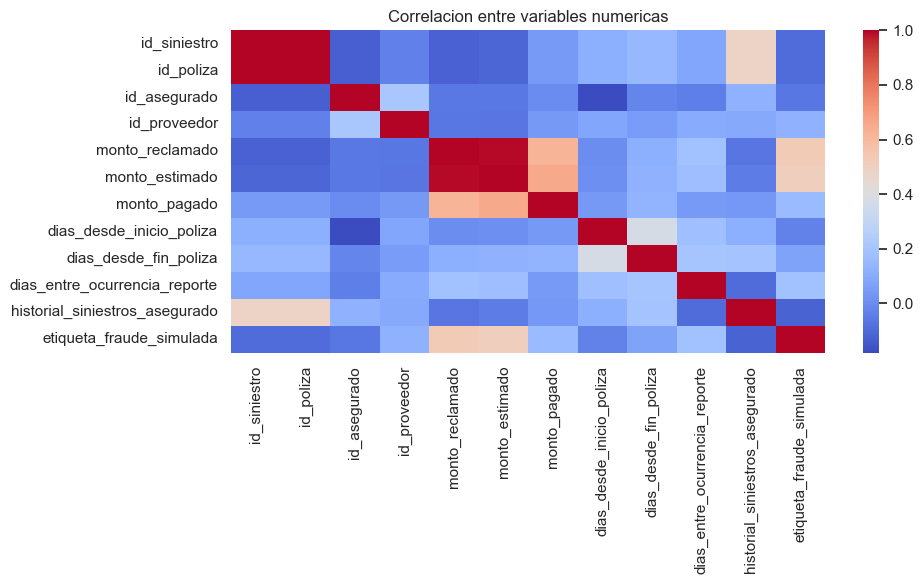

In [30]:
num_for_corr = siniestros.select_dtypes(include=["number"]).copy()
plt.figure(figsize=(10, 6))
sns.heatmap(num_for_corr.corr(), cmap="coolwarm", annot=False)
plt.title("Correlacion entre variables numericas")
plt.tight_layout()
plt.show()